In [3]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn'], returncode=0)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
# Load the dataset
df = pd.read_csv(r'C:\Users\Akshay kumar\Desktop\project\spam.csv', encoding='latin-1')

# Keep only the useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Preview
print(df.shape)
df.head(10)

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


label
ham     4825
spam     747
Name: count, dtype: int64

Total messages: 5572
Spam messages: 747
Ham messages: 4825


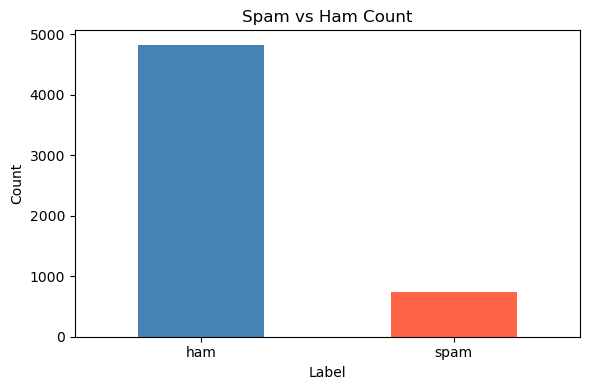

In [14]:
# Check spam vs ham count
print(df['label'].value_counts())
print()
print(f"Total messages: {len(df)}")
print(f"Spam messages: {df[df['label']=='spam'].shape[0]}")
print(f"Ham messages: {df[df['label']=='ham'].shape[0]}")

# Visualize
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Spam vs Ham Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'[^\w\s]', '', text)          # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

df['cleaned'] = df['message'].apply(clean_text)

# Compare original vs cleaned
print("Original:", df['message'][0])
print("Cleaned: ", df['cleaned'][0])

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:  go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [18]:
# Convert labels to numbers (ham=0, spam=1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label_num'], test_size=0.2, random_state=42
)

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

# Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train_tf, y_train)

print("Model trained successfully!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Model trained successfully!
Training samples: 4457
Testing samples:  1115


Accuracy: 97.31%

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



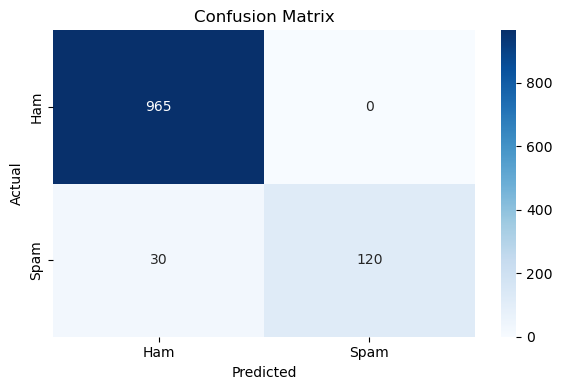

In [20]:
# Predictions
y_pred = model.predict(X_test_tf)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print()

# Detailed report
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [22]:
def predict_spam(message):
    cleaned = clean_text(message)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    label = "🚨 SPAM" if prediction == 1 else "✅ HAM (Not Spam)"
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print(f"Confidence: {max(probability)*100:.2f}%")
    print("-" * 50)

# Test with sample messages
predict_spam("Congratulations! You've won a free iPhone. Click here to claim now!")
predict_spam("Hey, are we still meeting for lunch tomorrow?")
predict_spam("URGENT: Your bank account has been compromised. Call now!")
predict_spam("Can you send me the notes from today's class?")

Message: Congratulations! You've won a free iPhone. Click here to claim now!
Prediction: 🚨 SPAM
Confidence: 94.04%
--------------------------------------------------
Message: Hey, are we still meeting for lunch tomorrow?
Prediction: ✅ HAM (Not Spam)
Confidence: 99.67%
--------------------------------------------------
Message: URGENT: Your bank account has been compromised. Call now!
Prediction: ✅ HAM (Not Spam)
Confidence: 52.64%
--------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: ✅ HAM (Not Spam)
Confidence: 92.12%
--------------------------------------------------


In [26]:
import subprocess
subprocess.run(["pip", "install", "wordcloud"])

CompletedProcess(args=['pip', 'install', 'wordcloud'], returncode=0)

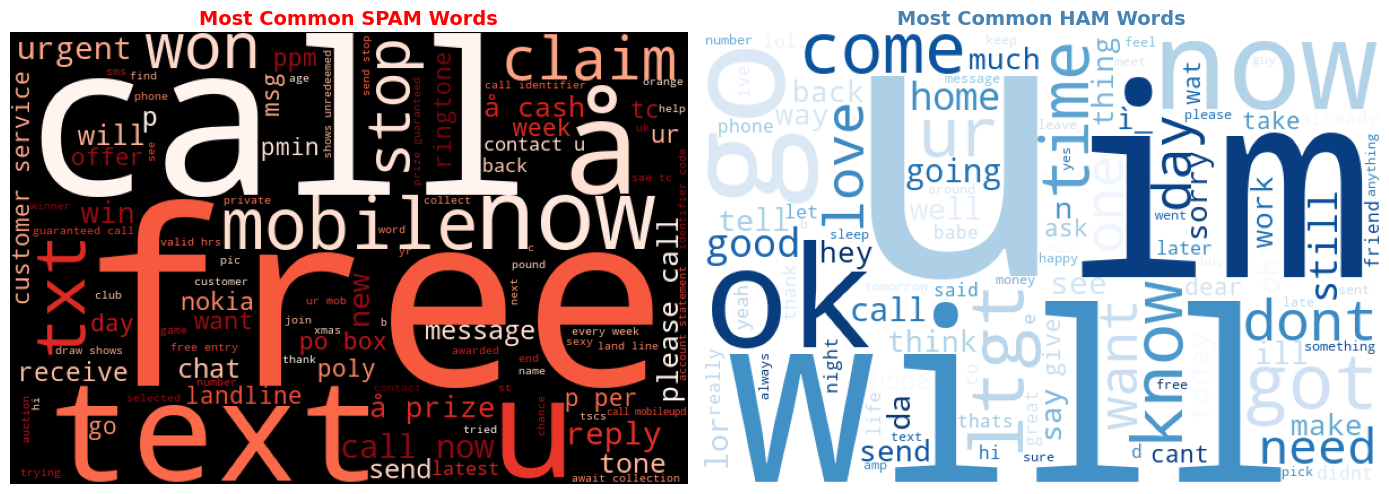

In [28]:
from wordcloud import WordCloud

spam_words = ' '.join(df[df['label'] == 'spam']['cleaned'])
ham_words = ' '.join(df[df['label'] == 'ham']['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spam word cloud
wc_spam = WordCloud(width=600, height=400, background_color='black',
                    colormap='Reds', max_words=100).generate(spam_words)
axes[0].imshow(wc_spam)
axes[0].axis('off')
axes[0].set_title('Most Common SPAM Words', fontsize=14, fontweight='bold', color='red')

# Ham word cloud
wc_ham = WordCloud(width=600, height=400, background_color='white',
                   colormap='Blues', max_words=100).generate(ham_words)
axes[1].imshow(wc_ham)
axes[1].axis('off')
axes[1].set_title('Most Common HAM Words', fontsize=14, fontweight='bold', color='steelblue')

plt.tight_layout()
plt.show()